# MERFISH onto Visium H&E, from annotated points

The same pair as [merfish-visium](merfish-visium.ipynb), with landmarks picked interactively
rather than hardcoded: five named regions, several points each, saved per side.

Upstream's equivalent is `merfish-visium-alignment-with-point-annotator`. Its own annotator is a
plotly click handler; what it saves is two dicts keyed by region name, and those are the input
here.

STalign's own version of this analysis: [`merfish-visium-alignment-with-point-annotator`](https://github.com/JEFworks-Lab/STalign/blob/b2068edc98974efa54537eca194736e177bbe11d/docs/notebooks/merfish-visium-alignment-with-point-annotator.ipynb).


## Inputs

In [1]:
import matplotlib.pyplot as plt
import numpy as np, pandas as pd, spatialdata as sd
from spatialdata.models import Image2DModel, PointsModel
from spatialdata.transformations import get_transformation
from squidpy.experimental.im import rasterize_points
from squidpy.experimental.tl import align_stalign_image, stalign_transform_points

# `sigmaM`, `sigmaB` and `sigmaA` are in the images' own intensity units, and upstream states
# its values for both sides mapped onto [0, 1]. A raw density raster of 167k cells has a mean
# near 3 and a max well above 10, which leaves widths of ~0.1 about a hundred times too tight:
# the fit then converges on an objective that has stopped measuring the overlap.
def unit(a):
    a = np.asarray(a, dtype=float)
    return (a - a.min()) / np.ptp(a)

def as_image(rgb, key):
    return sd.SpatialData(images={key: Image2DModel.parse(
        unit(np.moveaxis(rgb, -1, 0)), dims=('c', 'y', 'x'))})

def rasterized(xy, dx):
    sdata = sd.SpatialData(points={'cells': PointsModel.parse(xy)})
    rasterize_points(sdata, 'cells', dx=dx, blur=1.0, key_added='section')
    element = sdata.images['section']
    sdata.images['section'] = Image2DModel.parse(
        unit(np.asarray(element)), dims=('c', 'y', 'x'),
        transformations={'global': get_transformation(element, 'global')})
    return sdata

MERFISH = ('merfish_data/datasets_mouse_brain_map_BrainReceptorShowcase'
           '_Slice2_Replicate3_cell_metadata_S2R3.csv.gz')
cells = pd.read_csv(MERFISH)
xy = np.c_[cells['center_x'], cells['center_y']].astype(float)

he = plt.imread('visium_data/tissue_hires_image.png')[..., :3]
visium = as_image(he, 'he')
merfish = rasterized(xy, 30.0)
print(f'{len(xy)} cells rasterized to {tuple(np.asarray(merfish["section"]).shape)}, '
      f'H&E is {he.shape}')

/localscratch/selman.ozleyen/stalign-nb-39810190/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


85958 cells rasterized to (1, 256, 336), H&E is (2000, 1838, 3)


Row order is the correspondence, so both sides are flattened in the same key order. Each side's
points are in that side's own units -- microns against pixels -- and nothing restates them: the
elements carry their placement and the solver reads it off them.

In [2]:
picked = {side: np.load(f'visium_data/{name}_points.npy', allow_pickle=True).item()
          for side, name in (('query', 'Merfish_S2_R3'), ('ref', 'tissue_hires_image'))}
regions = list(picked['ref'])
paired = {side: np.array([p for r in regions for p in picked[side][r]], dtype=float)
          for side in picked}
print(f'{len(paired["ref"])} pairs over {len(regions)} regions: {", ".join(regions)}')

12 pairs over 5 regions: RSP, DG-sg, CA, PAA, MEAav


## The fit

Upstream's own solver values, which differ from the hardcoded-landmark variant.

In [3]:
fit = align_stalign_image(
    visium, merfish, image_key=('he', 'section'),
    landmarks_ref=paired['ref'], landmarks_query=paired['query'],
    niter=200, sigmaM=0.18, sigmaB=0.18, sigmaA=0.18, sigmaP=2e-1,
    epL=5e-11, epT=5e-4, epV=5e1,
)
print(f'{fit["n_iter"]} iterations, objective '
      f'{float(fit["energies"][0]):.0f} -> {float(fit["energies"][-1]):.0f}')

200 iterations, objective 2445204 -> 648605


## Every cell, placed on the image

The H&E covers one hemisphere while the MERFISH section is a whole coronal slice, so part of it
has no tissue to land on. All the landmarks sit on the covered half, which is why the residual
below is small whatever happens to the other one.

landmark residual: median 0.8 px, worst 4.5 px
84% of cells land within the 1838 x 2000 image


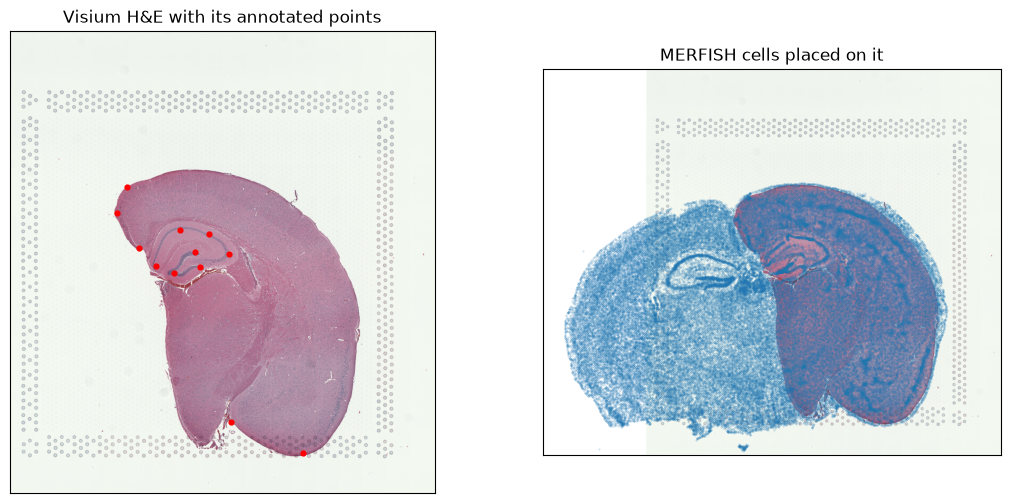

In [4]:
placed = np.asarray(stalign_transform_points(fit, xy))
residual = np.linalg.norm(np.asarray(stalign_transform_points(fit, paired['query'])) - paired['ref'], axis=1)
rows, columns = he.shape[:2]
inside = ((placed[:, 0] >= 0) & (placed[:, 0] < columns)
          & (placed[:, 1] >= 0) & (placed[:, 1] < rows))
print(f'landmark residual: median {np.median(residual):.1f} px, worst {residual.max():.1f} px')
print(f'{100 * inside.mean():.0f}% of cells land within the {columns} x {rows} image')

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
ax[0].imshow(he); ax[0].scatter(*paired['ref'].T, s=12, c='red')
ax[0].set_title('Visium H&E with its annotated points')
ax[1].imshow(he); ax[1].scatter(*placed.T, s=0.12, alpha=0.3, c='tab:blue')
ax[1].set_title('MERFISH cells placed on it')
for a in ax:
    a.set_xticks([]); a.set_yticks([])